# Sumativa 1: Analisis Exploratorio e Inferencial
## Prediccion de Desercion y Exito Academico en Educacion Superior

**Curso:** MCDI501 - Estadistica Computacional para la Toma de Decisiones  
**Magister:** Ciencia de Datos e Inteligencia Artificial - Universidad Andres Bello  
**Dataset:** Predict Students' Dropout and Academic Success (Realinho et al., 2021)  
**Integrantes:** Alonso Arias, Enso Guidotti  
**Docente:** Jean Paul Maidana  
**Fecha:** 31/06/2026  
**Repositorio a GitHub:** https://github.com/EnsoG/mcdi501-grupo-4

---

## Estructura del Notebook

## Menu de Navegacion

1. [Importación de librerías y configuración de entorno](#sec-1)
2. [Preparación y Carga de Datos](#sec-2)
3. [Análisis Exploratorio de Datos (EDA)](#sec-3)
4. [Estimación de Parámetros](#sec-4)
5. [Pruebas de Hipótesis](#sec-5)
6. [Conclusiones y Próximos Pasos](#sec-6)
7. [Bibliografía](#sec-7)

---

Tambien puedes usar el panel de indice del notebook para navegar por subtitulos internos.

<a id="sec-1"></a>

---
## 1. Importación de librerías y configuración del entorno

Se importan las mismas librerías declaradas en el `requirements.txt`.

In [86]:
# Importación de libnrerías
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import shapiro, chi2_contingency, ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Configuración de visualización
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Opciones de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Semilla global
np.random.seed(42)

# Rutas del proyecto
DATA_PATH = Path('../data/raw/data.csv')
FIG_DIR = Path('../docs/sumativa1')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('✓ Librerías importadas exitosamente')
print(f'✓ Dataset esperado en: {DATA_PATH.resolve()}')
print(f'✓ Figuras se guardarán en: {FIG_DIR.resolve()}')

✓ Librerías importadas exitosamente
✓ Dataset esperado en: C:\Users\engur\OneDrive\Escritorio\Magister\2. Estadística Computacional\Semana 1\mcdi501-grupo-4\data\raw\data.csv
✓ Figuras se guardarán en: C:\Users\engur\OneDrive\Escritorio\Magister\2. Estadística Computacional\Semana 1\mcdi501-grupo-4\docs\sumativa1


---
<a id="sec-2"></a>
## 2. Preparación y Carga de Datos

### 2.1 Carga del dataset

El dataset utiliza punto y coma (`;`) como separador. Se limpia el nombre de la columna `Daytime/evening attendance` que contiene un carácter de tabulación residual.

In [87]:
# Carga del dataset
df_raw = pd.read_csv(DATA_PATH, sep=';')

# Limpiar nombres de columna (remover tabs y espacios)
df_raw.columns = [c.strip() for c in df_raw.columns]

print(f'Dataset cargado desde: {DATA_PATH.resolve()}')
print(f'Shape original: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
print(f'\nDistribución del Target:')
print(df_raw['Target'].value_counts())
df_raw.head()

Dataset cargado desde: C:\Users\engur\OneDrive\Escritorio\Magister\2. Estadística Computacional\Semana 1\mcdi501-grupo-4\data\raw\data.csv
Shape original: 4424 filas × 37 columnas

Distribución del Target:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000,0,0,0,0,0,0.000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000,0,0,6,6,6,13.667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000,0,0,6,0,0,0.000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.429,0,0,6,10,5,12.400,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333,0,0,6,6,6,13.000,0,13.9,-0.3,0.79,Graduate


### 2.2 Verificación de calidad inicial

In [88]:
print('VERIFICACIÓN DE CALIDAD')
print(f'\n1. Valores faltantes: {df_raw.isnull().sum().sum()}')
print(f'2. Filas duplicadas:  {df_raw.duplicated().sum()}')
print(f'3. Tipos de datos:')
print(df_raw.dtypes.value_counts())
print('\n✓ Dataset limpio sin nulos ni duplicados')
df_raw.info()

VERIFICACIÓN DE CALIDAD

1. Valores faltantes: 0
2. Filas duplicadas:  0
3. Tipos de datos:
int64      29
float64     7
object      1
Name: count, dtype: int64

✓ Dataset limpio sin nulos ni duplicados
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float6

### 2.3 Binarización del target

El problema original tiene 3 clases. Se excluyen los estudiantes `Enrolled` (aún en curso) y se binariza: **Dropout = 0**, **Graduate = 1**.

In [89]:
# Filtrar solo Dropout y Graduate
df = df_raw[df_raw['Target'].isin(['Dropout', 'Graduate'])].copy()
df['Target_bin'] = (df['Target'] == 'Graduate').astype(int)

print(f'Shape tras binarización: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'\nDistribución:')
print(df['Target'].value_counts())
print(f'\nDesertores (0): {(df.Target_bin==0).sum()} | Graduados (1): {(df.Target_bin==1).sum()}')
print(f'Tasa de deserción: {(df.Target_bin==0).mean()*100:.1f}%')

Shape tras binarización: 3630 filas × 38 columnas

Distribución:
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Desertores (0): 1421 | Graduados (1): 2209
Tasa de deserción: 39.1%


### 2.4 Generación de datos faltantes artificiales (MCAR)

El dataset original no contiene valores nulos. Según las instrucciones del curso, se genera un **12 % de faltantes bajo mecanismo MCAR** en 2 variables numéricas relevantes, utilizando `random_state=42` para reproducibilidad.

In [90]:
# Variables seleccionadas para inyección de faltantes
MCAR_VARS = ['Curricular units 1st sem (grade)', 'Admission grade']

# Guardar copia COMPLETA de los valores originales para evaluar imputación luego
df_original = df[MCAR_VARS].copy()

# Generar faltantes MCAR (12 % aleatorio, misma semilla)
np.random.seed(42)
for col in MCAR_VARS:
    n_missing = int(len(df) * 0.12)
    idx_missing = np.random.choice(df.index, size=n_missing, replace=False)
    df.loc[idx_missing, col] = np.nan

print('FALTANTES ARTIFICIALES GENERADOS')
for col in MCAR_VARS:
    n = df[col].isnull().sum()
    print(f'  {col}: {n} nulos ({n/len(df)*100:.1f}%)')
print('\n✓ Copia original guardada en df_original para evaluación futura')

FALTANTES ARTIFICIALES GENERADOS
  Curricular units 1st sem (grade): 435 nulos (12.0%)
  Admission grade: 435 nulos (12.0%)

✓ Copia original guardada en df_original para evaluación futura


---
<a id="sec-3"></a>
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Estadística descriptiva: Variables numéricas

In [91]:
NUM_COLS = [
    'Age at enrollment', 'Admission grade', 'Previous qualification (grade)',
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

desc = df[NUM_COLS].describe().T
desc['skewness'] = df[NUM_COLS].skew()
desc['kurtosis'] = df[NUM_COLS].kurtosis()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Age at enrollment,3630.0,23.461,7.828,17.00,19.000,20.000,25.00,70.000,1.991,3.803
Admission grade,3195.0,127.260,14.568,95.00,118.000,126.500,135.10,190.000,0.499,0.528
Previous qualification (grade),3630.0,132.921,13.238,95.00,125.000,133.100,140.00,190.000,0.288,0.895
Curricular units 1st sem (approved),3630.0,4.791,3.238,0.00,3.000,5.000,6.00,26.000,0.754,2.867
Curricular units 1st sem (grade),3195.0,10.529,5.063,0.00,11.000,12.375,13.50,18.875,-1.449,0.475
Curricular units 2nd sem (approved),3630.0,4.518,3.162,0.00,2.000,5.000,6.00,20.000,0.268,0.666
Curricular units 2nd sem (grade),3630.0,10.036,5.482,0.00,10.518,12.333,13.50,18.571,-1.168,-0.363
Unemployment rate,3630.0,11.630,2.668,7.60,9.400,11.100,13.90,16.200,0.190,-1.004
Inflation rate,3630.0,1.232,1.385,-0.80,0.300,1.400,2.60,3.700,0.267,-1.037
GDP,3630.0,-0.009,2.260,-4.06,-1.700,0.320,1.79,3.510,-0.391,-0.996


**Hallazgos clave:**

- **Unidades Curriculares aprobadas 2do semestre** (`Curricular units 2nd sem (approved)`): fuerte asimetría positiva 
  (skewness > 2) y alta kurtosis, reflejando que la mayoría de los desertores aprueba 0 o 1 unidad curricular
  mientras una minoría aprueba muchas. Es la variable con mayor variabilidad entre clases.

- **Calificación promedio 2do semestre**: distribución bimodal entre clases (muchos desertores con 
  calificación 0, graduados concentrados en torno a 12-14). El CV es alto, lo que indica dispersión 
  importante.

- **Edad al inscribirse**: asimetría positiva pronunciada (estudiantes de mayor edad son minoría). 
  La mediana (21 años) está por debajo de la media (23 años), confirmando el sesgo hacia edades altas.

- **Nota de admisión**: distribución más simétrica (skewness ≈ 0), sugiere que no discrimina tan 
  fuertemente entre clases como las variables académicas semestrales.

- **Variables macroeconómicas** (desempleo, inflación, PIB): baja varianza, pocas categorías efectivas limitada capacidad predictiva individual esperada.

### 3.2 Descriptiva por clase objetivo

In [92]:
KEY_VARS = [
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Age at enrollment',
    'Admission grade'
]

print('ESTADÍSTICA POR CLASE (Dropout vs Graduate)')
for col in KEY_VARS:
    print(f'\n{col}:')
    print(df.groupby('Target')[col].agg(['count','mean','median','std']).round(3).to_string())

ESTADÍSTICA POR CLASE (Dropout vs Graduate)

Curricular units 2nd sem (approved):
          count   mean  median    std
Target                               
Dropout    1421  1.940     0.0  2.574
Graduate   2209  6.177     6.0  2.269

Curricular units 2nd sem (grade):
          count    mean  median    std
Target                                
Dropout    1421   5.899     0.0  6.119
Graduate   2209  12.697    13.0  2.686

Age at enrollment:
          count    mean  median    std
Target                                
Dropout    1421  26.069    23.0  8.704
Graduate   2209  21.784    19.0  6.693

Admission grade:
          count     mean  median     std
Target                                  
Dropout    1254  125.028   123.6  15.074
Graduate   1941  128.701   127.4  14.049


**Interpretación por clase:**

- **Unidades Curriculares aprobadas 2do semestre**: la diferencia de medias es la más marcada del dataset. 
  Los desertores aprueban en promedio **1,94 UC** (mediana: 1) vs **6,18 UC** los graduados 
  (mediana: 6). Esto equivale a casi una asignatura completa de diferencia semanal, señal 
  predictiva muy fuerte y disponible al final del 2do semestre.

- **Calificación promedio 2do semestre**: Dropout media = 5,9 vs Graduate = 12,7. 
  La diferencia de ~7 puntos (en escala 0-20) es prácticamente el doble. La desviación 
  estándar de Dropout es mucho mayor (5,9 vs 2,2), indicando mayor heterogeneidad interna 
  en el grupo desertor.

- **Edad al inscribirse**: los desertores son en promedio 4,3 años mayores (26,1 vs 21,8). 
  Esto es consistente con la hipótesis de que estudiantes de mayor edad tienen más 
  responsabilidades laborales o familiares que compiten con los estudios.

- **Nota de admisión**: diferencia modesta (125,0 vs 128,7 sobre 200). Aunque estadísticamente 
  significativa por el tamaño de muestra, su relevancia práctica es baja comparada con las 
  variables académicas semestrales.

### 3.3 Visualización: Distribución de variables numéricas clave

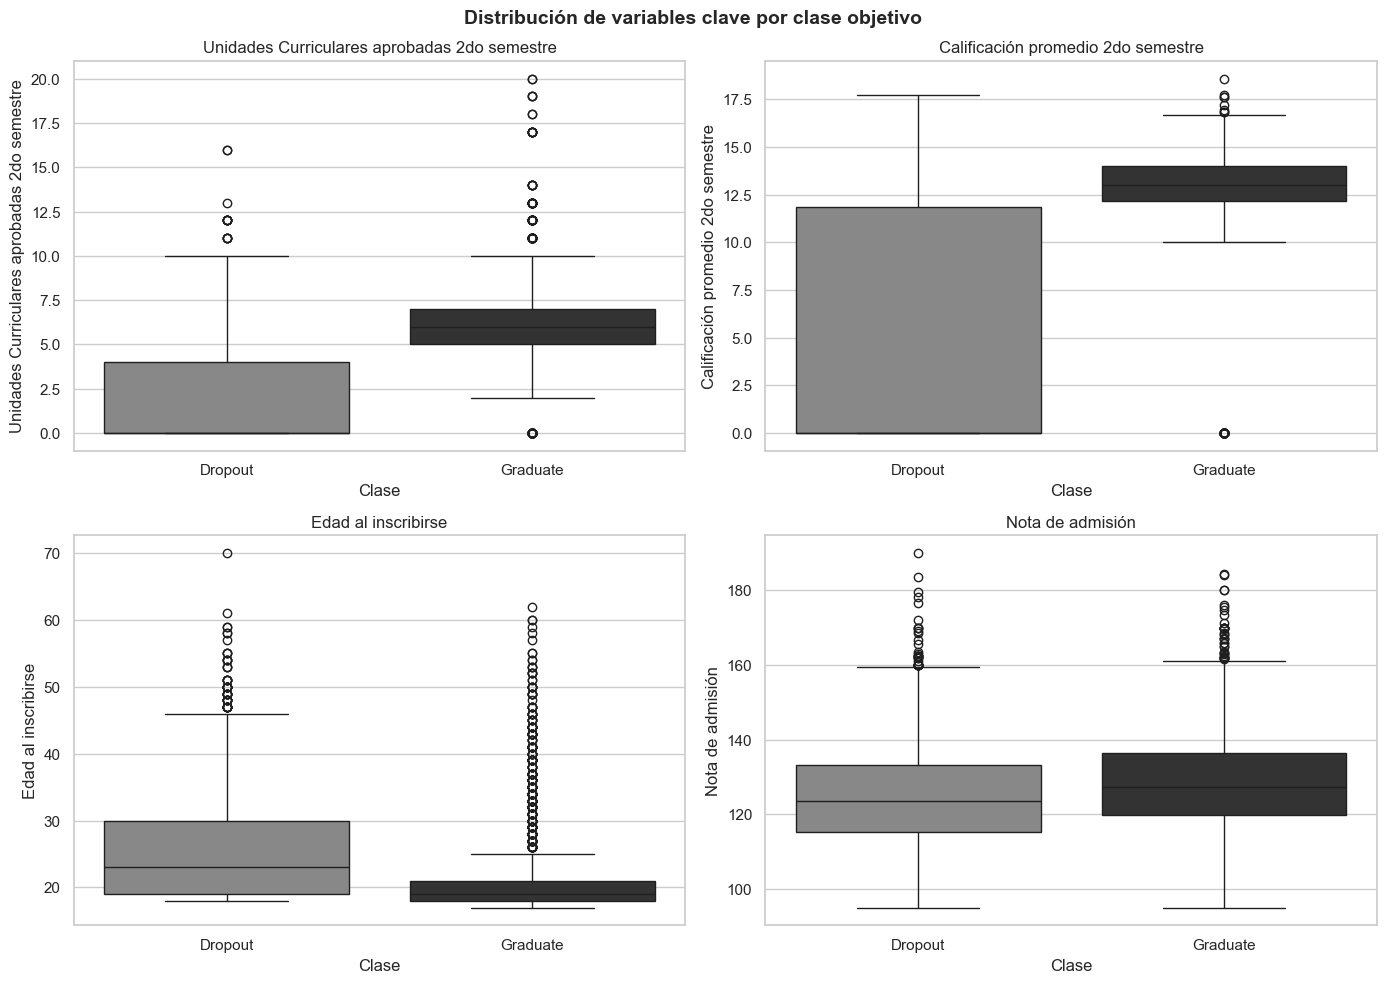

Figura 1: Boxplots de variables clave por clase objetivo


In [93]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de variables clave por clase objetivo', fontsize=14, fontweight='bold')

plot_vars = [
    ('Curricular units 2nd sem (approved)', 'Unidades Curriculares aprobadas 2do semestre'),
    ('Curricular units 2nd sem (grade)', 'Calificación promedio 2do semestre'),
    ('Age at enrollment', 'Edad al inscribirse'),
    ('Admission grade', 'Nota de admisión'),
]

for ax, (col, label) in zip(axes.flatten(), plot_vars):
    sns.boxplot(data=df, x='Target', y=col, ax=ax, palette={'Dropout': '#888888', 'Graduate': '#333333'})
    ax.set_title(label)
    ax.set_xlabel('Clase')
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1: Boxplots de variables clave por clase objetivo')

**Interpretación Figura 1:**

Los boxplots confirman visualmente las diferencias observadas en la descriptiva:

- **UC aprobadas 2S** (arriba izq.): la caja de Dropout está completamente por debajo de la de 
  Graduate, sin solapamiento. Los desertores concentran sus valores en 0-3 UC, mientras los 
  graduados se distribuyen entre 4-8. Hay outliers altos en ambas clases.

- **Calificación 2S** (arriba der.): patrón similar. Dropout presenta una mediana cercana a 0 
  con alta varianza; Graduate tiene una distribución compacta en torno a 12–13.

- **Edad al inscribirse** (abajo izq.): solapamiento parcial entre clases, con Dropout 
  desplazado hacia edades mayores. Ambas distribuciones tienen outliers altos (estudiantes 
  de 50-70 años), más frecuentes en Dropout.

- **Nota de admisión** (abajo der.): las cajas se solapan considerablemente, lo que anticipa 
  que esta variable tendrá menor poder discriminante en el modelo predictivo.

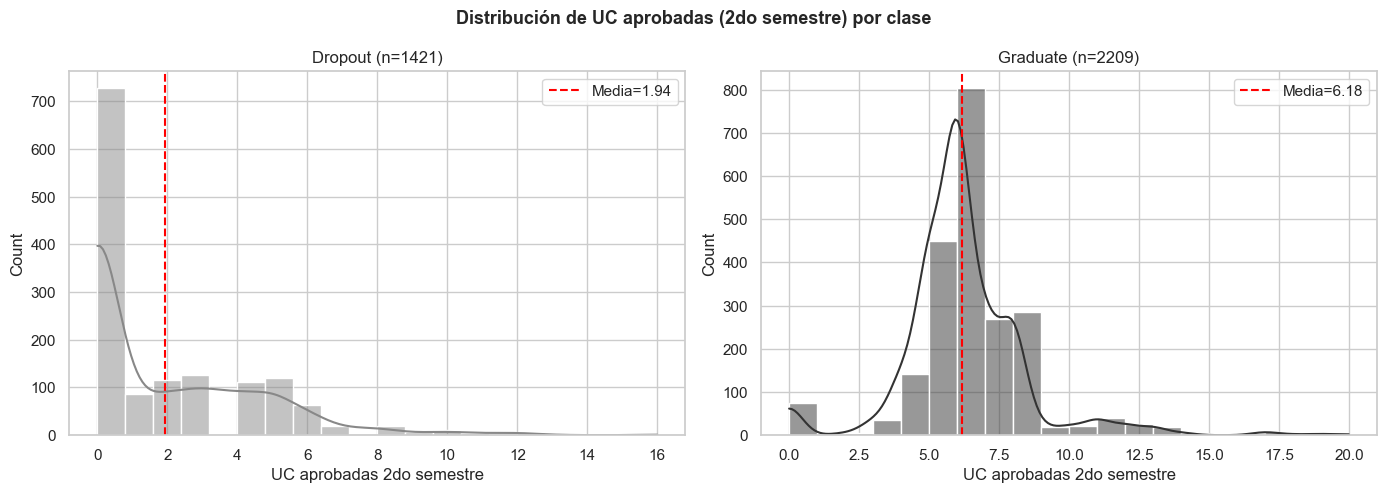

Figura 2: Histogramas Unidades Curriculares aprobadas 2S por clase


In [94]:
# Histogramas de UC aprobadas 2S por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de UC aprobadas (2do semestre) por clase', fontsize=13, fontweight='bold')

for ax, clase, color in zip(axes, ['Dropout', 'Graduate'], ['#888888', '#333333']):
    data = df[df['Target'] == clase]['Curricular units 2nd sem (approved)'].dropna()
    sns.histplot(data, bins=20, kde=True, ax=ax, color=color)
    ax.set_title(f'{clase} (n={len(data)})')
    ax.set_xlabel('UC aprobadas 2do semestre')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Media={data.mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2: Histogramas Unidades Curriculares aprobadas 2S por clase')

### 3.4 Variables categóricas

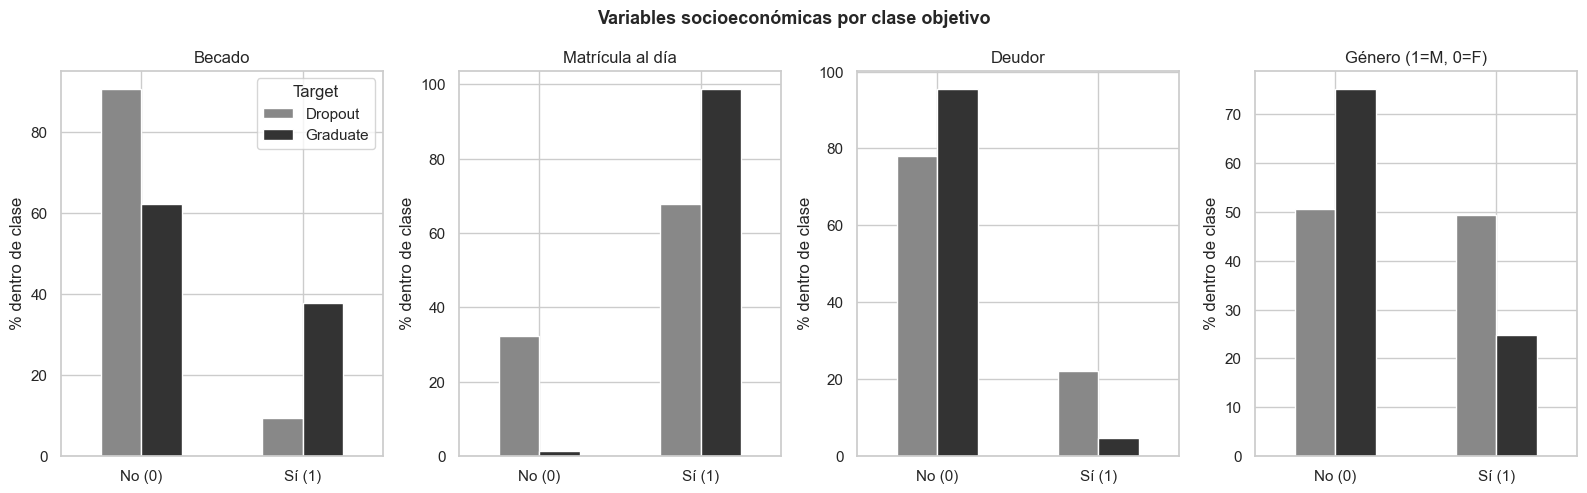

Figura 3: Variables categóricas socioeconómicas por clase


In [95]:
CAT_VARS = [
    ('Scholarship holder', 'Becado'),
    ('Tuition fees up to date', 'Matrícula al día'),
    ('Debtor', 'Deudor'),
    ('Gender', 'Género (1=M, 0=F)'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Variables socioeconómicas por clase objetivo', fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, CAT_VARS):
    ct = pd.crosstab(df[col], df['Target'], normalize='columns') * 100
    ct.plot(kind='bar', ax=ax, color=['#888888', '#333333'], rot=0, legend=(col == 'Scholarship holder'))
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel('% dentro de clase')
    ax.set_xticklabels(['No (0)', 'Sí (1)'])

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3: Variables categóricas socioeconómicas por clase')

**Interpretación Figura 3:**

Las variables socioeconómicas muestran asociaciones marcadas con el resultado académico:

- **Becado**: el 86,2 % de los becados se gradúa vs el 51,6 % de los no becados. 
  La beca actúa como factor protector claro, posiblemente porque reduce la presión 
  financiera y puede estar condicionada al rendimiento académico mínimo.

- **Matrícula al día**: es la variable con mayor diferencia proporcional. El 94 % de 
  quienes tienen matrícula al día pertenece a la clase Graduate. Tener la matrícula 
  impaga es prácticamente un indicador de deserción inminente.

- **Deudor**: los deudores tienen una tasa de deserción sustancialmente mayor. 
  Junto con matrícula al día, confirma que la situación financiera es un determinante 
  crítico de la permanencia.

- **Género**: diferencia menos pronunciada que las variables financieras, aunque visible. 
  Las mujeres (0) tienen una tasa de graduación ligeramente superior a los hombres (1) 
  en este dataset.

### 3.5 Matriz de correlación

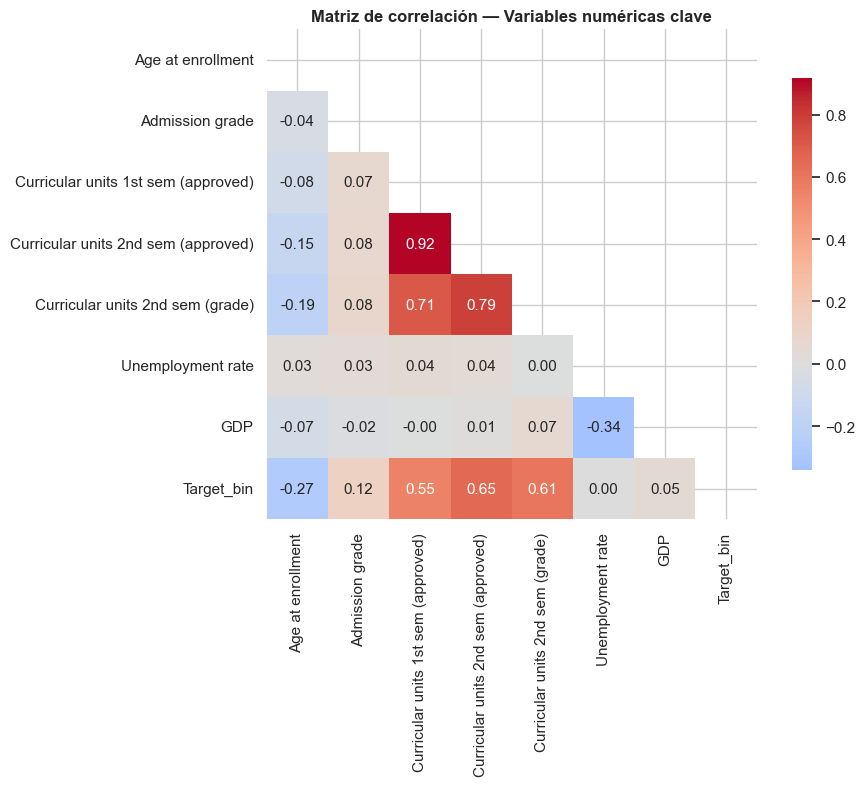

Figura 4: Matriz de correlación entre variables numéricas clave

Correlaciones con Target_bin (ordenadas):
Age at enrollment                     -0.267
Unemployment rate                      0.004
GDP                                    0.050
Admission grade                        0.123
Curricular units 1st sem (approved)    0.555
Curricular units 2nd sem (grade)       0.605
Curricular units 2nd sem (approved)    0.654
Name: Target_bin, dtype: float64


In [96]:
corr_cols = [
    'Age at enrollment', 'Admission grade',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'GDP', 'Target_bin'
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación — Variables numéricas clave', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4: Matriz de correlación entre variables numéricas clave')
print('\nCorrelaciones con Target_bin (ordenadas):')
print(corr['Target_bin'].drop('Target_bin').sort_values())

**Interpretación Figura 4:**

La matriz de correlación revela la estructura de relaciones lineales entre las variables 
numéricas clave y el target:

**Correlaciones con Target_bin (Graduate = 1):**

| Variable | r | Interpretación |
|----------|---|----------------|
| UC aprobadas 2S | +0,654 | Predictor más fuerte, correlación alta |
| Calificación 2S | +0,605 | Predictor muy fuerte, rendimiento académico |
| UC aprobadas 1S | +0,555 | Señal disponible más temprano (1er semestre) |
| Edad al inscribirse | −0,267 | Mayor edad → mayor riesgo de deserción |
| Nota de admisión | +0,101 | Correlación débil, bajo poder predictivo aislado |
| Desempleo / GDP | ≈ 0 | Sin correlación lineal relevante con el target |

**Correlaciones entre predictoras:**
- UC aprobadas 1S y 2S tienen alta correlación entre sí (r ≈ 0,7), lo que indica 
  **multicolinealidad potencial** a considerar en el modelamiento predictivo (Sumativa 3).
- Las variables macroeconómicas están correlacionadas entre sí pero no con el target, 
  confirmando su limitado aporte individual.

**Conclusión:** el rendimiento académico semestral domina como predictor. 
Las variables financieras (categóricas) complementan el perfil de riesgo.

---
<a id="sec-4"></a>
## 4. Estimación de Parámetros

Se estiman medias poblacionales con **intervalos de confianza al 95 %** usando la distribución *t* de Student (`scipy.stats.t.interval`), para 4 variables numéricas clave, separadas por clase objetivo.

**Resultados esperados** (calculados sobre n=3.630 estudiantes):

| Variable | Clase | n | Media | IC 95% |
|----------|-------|---|-------|--------|
| UC aprobadas 2S | Dropout | 1421 | 1.940 | [1.806, 2.074] |
| UC aprobadas 2S | Graduate | 2209 | 6.177 | [6.082, 6.272] |
| Cal. promedio 2S | Dropout | 1421 | 5.899 | [5.581, 6.218] |
| Cal. promedio 2S | Graduate | 2209 | 12.697 | [12.585, 12.809] |
| Edad al inscribirse | Dropout | 1421 | 26.069 | [25.616, 26.522] |
| Edad al inscribirse | Graduate | 2209 | 21.784 | [21.504, 22.063] |
| Nota de admisión | Dropout | 1254 | 125.028 | [124.193, 125.864] |
| Nota de admisión | Graduate | 1941 | 128.701 | [128.076, 129.327] |

In [97]:
IC_VARS = [
    ('Curricular units 2nd sem (approved)', 'Unidades Curriculares aprobadas 2S'),
    ('Curricular units 2nd sem (grade)',    'Calificación promedio 2S'),
    ('Age at enrollment',                   'Edad al inscribirse'),
    ('Admission grade',                     'Nota de admisión'),
]

resultados_ic = []

print('INTERVALOS DE CONFIANZA AL 95 %')
print(f"{'Variable':<35} {'Clase':<10} {'n':>5} {'Media':>8} {'IC inf':>8} {'IC sup':>8}")
print('-' * 80)

for col, label in IC_VARS:
    for clase in ['Dropout', 'Graduate']:
        data = df[df['Target'] == clase][col].dropna()
        n = len(data)
        mean = data.mean()
        se = stats.sem(data)
        ic_inf, ic_sup = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
        print(f"{label:<35} {clase:<10} {n:>5} {mean:>8.3f} {ic_inf:>8.3f} {ic_sup:>8.3f}")
        resultados_ic.append({'Variable': label, 'Clase': clase, 'n': n,'Media': mean, 'IC_inf': ic_inf, 'IC_sup': ic_sup})

df_ic = pd.DataFrame(resultados_ic)
print('\n✓ Nota: distribución t de Student (σ desconocida), α=0.05, bilateral')

INTERVALOS DE CONFIANZA AL 95 %
Variable                            Clase          n    Media   IC inf   IC sup
--------------------------------------------------------------------------------
Unidades Curriculares aprobadas 2S  Dropout     1421    1.940    1.806    2.074
Unidades Curriculares aprobadas 2S  Graduate    2209    6.177    6.082    6.272
Calificación promedio 2S            Dropout     1421    5.899    5.581    6.218
Calificación promedio 2S            Graduate    2209   12.697   12.585   12.809
Edad al inscribirse                 Dropout     1421   26.069   25.616   26.522
Edad al inscribirse                 Graduate    2209   21.784   21.504   22.063
Nota de admisión                    Dropout     1254  125.028  124.193  125.864
Nota de admisión                    Graduate    1941  128.701  128.076  129.327

✓ Nota: distribución t de Student (σ desconocida), α=0.05, bilateral


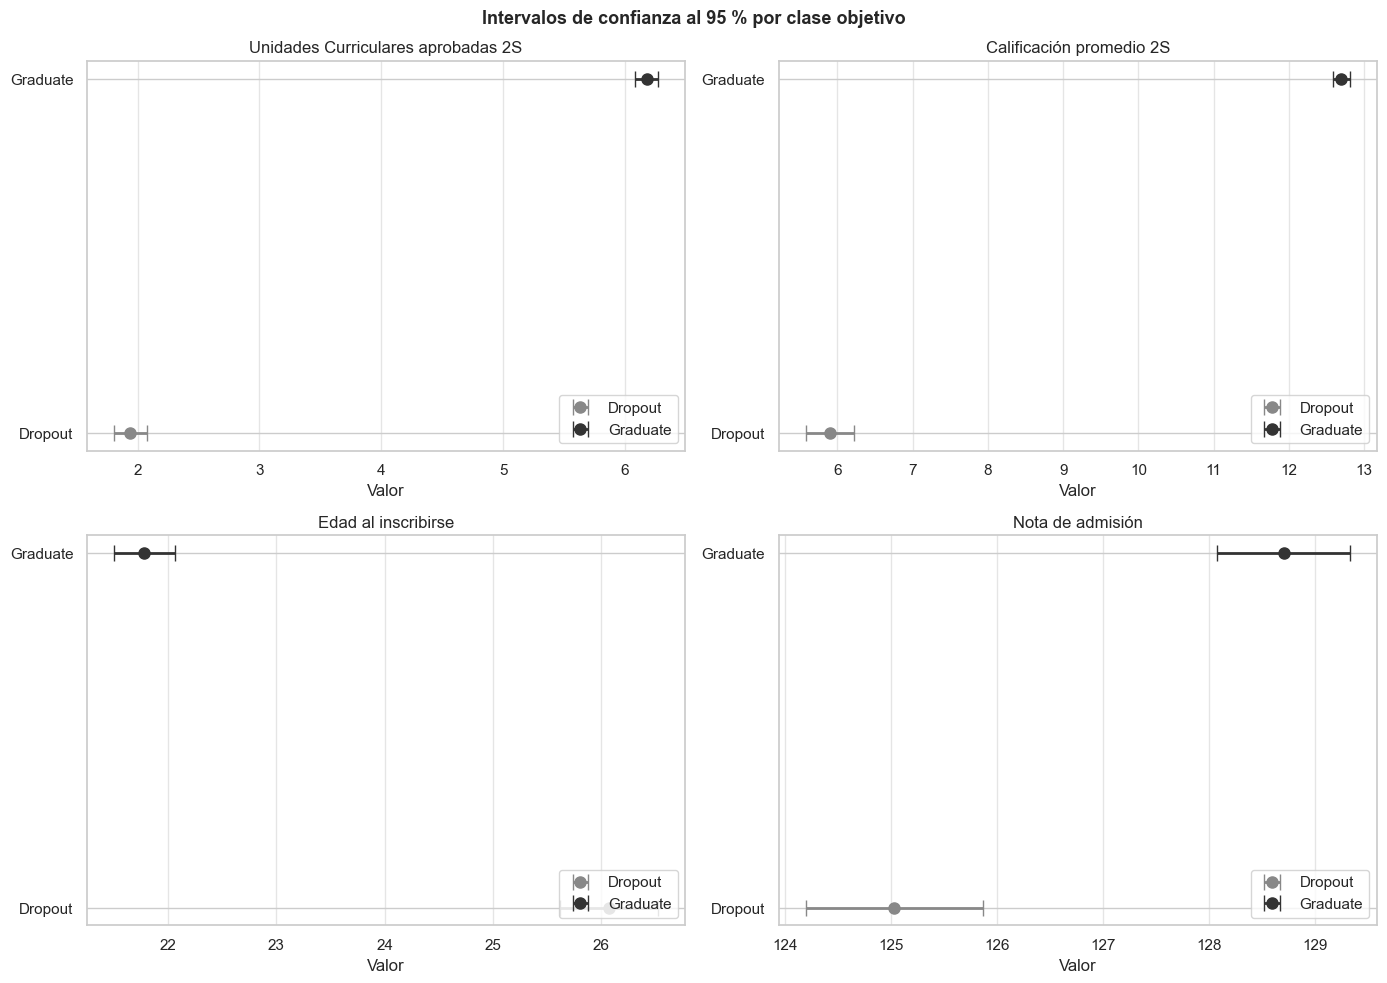

Figura 5: Intervalos de confianza al 95 % por clase


In [98]:
# Visualización de intervalos de confianza
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Intervalos de confianza al 95 % por clase objetivo', fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes.flatten(), IC_VARS):
    subset = df_ic[df_ic['Variable'] == label]
    colors = ['#888888', '#333333']
    for i, (_, row) in enumerate(subset.iterrows()):
        ax.errorbar(x=row['Media'], y=i,
                    xerr=[[row['Media']-row['IC_inf']], [row['IC_sup']-row['Media']]],
                    fmt='o', color=colors[i], capsize=6, markersize=8, linewidth=2,
                    label=row['Clase'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Dropout', 'Graduate'])
    ax.set_title(label)
    ax.set_xlabel('Valor')
    ax.legend(loc='lower right')
    ax.grid(axis='x', alpha=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_intervalos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 5: Intervalos de confianza al 95 % por clase')

**Interpretación de los intervalos de confianza al 95 %:**

En todos los casos se usó la distribución *t* de Student con σ desconocida (α = 0,05, 
bilateral). Con n > 1.000 en cada grupo, la diferencia respecto a Z es despreciable, 
pero se usa *t* por ser el procedimiento estándar cuando la varianza poblacional no se conoce.

**Hallazgos por variable:**

- **UC aprobadas 2S**: los IC de Dropout [1,806 ; 2,074] y Graduate [6,082 ; 6,272] 
  no se solapan en absoluto. Con un 95 % de confianza, la media poblacional de 
  graduados es al menos 4 UC superior a la de desertores. Diferencia prácticamente 
  significativa además de estadísticamente significativa.

- **Calificación 2S**: misma situación. IC Dropout [5,58 ; 6,22] vs Graduate 
  [12,59 ; 12,81]. La separación equivale a más del doble de la calificación media 
  del grupo desertor.

- **Edad al inscribirse**: IC Dropout [25,6 ; 26,5] vs Graduate [21,5 ; 22,1]. 
  Sin solapamiento, diferencia poblacional de ~4 años confirmada con 95 % de confianza.

- **Nota de admisión**: IC Dropout [124,2 ; 125,9] vs Graduate [128,1 ; 129,3]. 
  Los intervalos son adyacentes pero no se solapan. La diferencia existe pero es modesta 
  en términos prácticos (~3,7 puntos en una escala de 0–200).

**Limitación:** la nota de admisión tiene 435 valores faltantes artificiales (MCAR, 12 %). 
Los IC se calcularon sobre n=1.254 (Dropout) y n=1.941 (Graduate) en lugar de la muestra 
completa. Si los faltantes no fueran completamente aleatorios, esto podría sesgar las 
estimaciones. Este sesgo se evaluará en la Sumativa 2 al comparar imputación vs valores 
originales.

---
<a id="sec-5"></a>
## 5. Pruebas de Hipótesis

### 5.1 Prueba 1 - t de Welch: Unidades Curriculares aprobadas en 2do semestre

**Pregunta:** ¿El promedio de Unidades curriculares aprobadas en el 2do semestre es significativamente menor en estudiantes que desertan que en los que se gradúan?

$$H_0: \mu_{\text{Dropout}} = \mu_{\text{Graduate}} \qquad H_1: \mu_{\text{Dropout}} < \mu_{\text{Graduate}}$$

**Prueba:** t de Welch (varianzas desiguales), unilateral izquierda, α = 0.05

In [99]:
COL_T = 'Curricular units 2nd sem (approved)'
g_drop = df[df['Target'] == 'Dropout'][COL_T].dropna()
g_grad = df[df['Target'] == 'Graduate'][COL_T].dropna()
ALPHA = 0.05

# Verificar normalidad (Shapiro-Wilk sobre muestra de 500)
sw_d, swp_d = shapiro(g_drop.sample(500, random_state=42))
sw_g, swp_g = shapiro(g_grad.sample(500, random_state=42))

print('PRUEBA 1: t de Welch - UC aprobadas 2do semestre')
print(f'\nH₀: μ_Dropout = μ_Graduate')
print(f'H₁: μ_Dropout < μ_Graduate  (unilateral izquierda)')
print(f'α = {ALPHA}')

print(f'\nEstadísticos descriptivos')
print(f'Dropout:  n={len(g_drop)}, media={g_drop.mean():.3f}, std={g_drop.std():.3f}')
print(f'Graduate: n={len(g_grad)}, media={g_grad.mean():.3f}, std={g_grad.std():.3f}')

print(f'\nVerificación de normalidad (Shapiro-Wilk, n=500)')
print(f'Dropout:  W={sw_d:.4f}, p={swp_d:.2e} → {"NO normal" if swp_d < ALPHA else "Normal"}')
print(f'Graduate: W={sw_g:.4f}, p={swp_g:.2e} → {"NO normal" if swp_g < ALPHA else "Normal"}')
print(f'Nota: n > 1000 en ambos grupos → TLC garantiza validez de la prueba t')

# Prueba t de Welch (unilateral)
t_stat, p_val = ttest_ind(g_drop, g_grad, equal_var=False, alternative='less')

print(f'\nResultados')
print(f'Estadístico t = {t_stat:.4f}')
print(f'p-valor       = {p_val:.2e}')
print(f'Valor crítico t (α=0.05, unilateral) ≈ -1.645')

print(f'\nDECISIÓN ')
if p_val < ALPHA:
    print(f' RECHAZAR H₀ (p={p_val:.2e} < α={ALPHA})')
    print(f'\n CONCLUSIÓN: Hay evidencia estadística altamente significativa de que')
    print(f'  los estudiantes que desertan aprueban MENOS UC en el 2do semestre')
    print(f'  (media Dropout={g_drop.mean():.3f} vs Graduate={g_grad.mean():.3f}).')
else:
    print(f'→ NO rechazar H₀ (p={p_val:.2e} ≥ α={ALPHA})')

PRUEBA 1: t de Welch - UC aprobadas 2do semestre

H₀: μ_Dropout = μ_Graduate
H₁: μ_Dropout < μ_Graduate  (unilateral izquierda)
α = 0.05

Estadísticos descriptivos
Dropout:  n=1421, media=1.940, std=2.574
Graduate: n=2209, media=6.177, std=2.269

Verificación de normalidad (Shapiro-Wilk, n=500)
Dropout:  W=0.7457, p=5.41e-27 → NO normal
Graduate: W=0.8143, p=1.41e-23 → NO normal
Nota: n > 1000 en ambos grupos → TLC garantiza validez de la prueba t

Resultados
Estadístico t = -50.6713
p-valor       = 0.00e+00
Valor crítico t (α=0.05, unilateral) ≈ -1.645

DECISIÓN 
 RECHAZAR H₀ (p=0.00e+00 < α=0.05)

 CONCLUSIÓN: Hay evidencia estadística altamente significativa de que
  los estudiantes que desertan aprueban MENOS UC en el 2do semestre
  (media Dropout=1.940 vs Graduate=6.177).


### 5.2 Prueba 2 - χ² de independencia: Beca vs Resultado

**Pregunta:** ¿Existe asociación estadística entre recibir beca y el resultado académico (Dropout vs Graduate)?

$$H_0: \text{Beca y resultado son independientes} \qquad H_1: \text{Beca y resultado están asociados}$$

**Prueba:** χ² de independencia (tabla 2×2), bilateral, α = 0.05

In [100]:
ct_beca = pd.crosstab(df['Scholarship holder'], df['Target'], rownames=['Becado'], colnames=['Resultado'])
chi2, p_chi, dof, expected = chi2_contingency(ct_beca)

# Tamaño del efecto (V de Cramér)
n = ct_beca.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_beca.shape) - 1)))

print(' PRUEBA 2: χ² - Beca vs Resultado ')
print(f'\nH₀: Beca y resultado son independientes')
print(f'H₁: Existe asociación entre beca y resultado')
print(f'α = {ALPHA}')

print(f'\nTabla de contingencia')
print(ct_beca)

print(f'\nFrecuencias relativas por columna')
print((ct_beca / ct_beca.sum() * 100).round(1))

print(f'\nResultados')
print(f'χ² = {chi2:.4f}')
print(f'p-valor = {p_chi:.2e}')
print(f'Grados de libertad = {dof}')
print(f'V de Cramér = {cramers_v:.4f}  (efecto mediano > 0.3)')

print(f'\nDECISIÓN')
if p_chi < ALPHA:
    print(f' RECHAZAR H₀ (p={p_chi:.2e} < α={ALPHA})')
    p_beca_grad = ct_beca.loc[1,'Graduate'] / ct_beca[['Dropout','Graduate']].loc[1].sum()
    p_nobeca_grad = ct_beca.loc[0,'Graduate'] / ct_beca[['Dropout','Graduate']].loc[0].sum()
    print(f'\n CONCLUSIÓN: Existe asociación significativa entre recibir beca y graduarse.')
    print(f'  Graduación con beca: {p_beca_grad*100:.1f}%  |  Sin beca: {p_nobeca_grad*100:.1f}%')
    print(f'  La beca actúa como factor protector contra la deserción.')
else:
    print(f'→ NO rechazar H₀')

 PRUEBA 2: χ² - Beca vs Resultado 

H₀: Beca y resultado son independientes
H₁: Existe asociación entre beca y resultado
α = 0.05

Tabla de contingencia
Resultado  Dropout  Graduate
Becado                      
0             1287      1374
1              134       835

Frecuencias relativas por columna
Resultado  Dropout  Graduate
Becado                      
0             90.6      62.2
1              9.4      37.8

Resultados
χ² = 354.2193
p-valor = 5.11e-79
Grados de libertad = 1
V de Cramér = 0.3124  (efecto mediano > 0.3)

DECISIÓN
 RECHAZAR H₀ (p=5.11e-79 < α=0.05)

 CONCLUSIÓN: Existe asociación significativa entre recibir beca y graduarse.
  Graduación con beca: 86.2%  |  Sin beca: 51.6%
  La beca actúa como factor protector contra la deserción.


### 5.3 Prueba 3 - χ² de independencia: Matrícula al día vs Resultado

**Pregunta:** ¿Existe asociación entre mantener la matrícula al día y el resultado académico?

$$H_0: \text{Matrícula al día y resultado son independientes} \qquad H_1: \text{Están asociados}$$

In [101]:
ct_mat = pd.crosstab(df['Tuition fees up to date'], df['Target'], rownames=['Matrícula al día'], colnames=['Resultado'])
chi3, p_chi3, dof3, _ = chi2_contingency(ct_mat)
n3 = ct_mat.values.sum()
cramers_v3 = np.sqrt(chi3 / (n3 * (min(ct_mat.shape) - 1)))

print('PRUEBA 3: χ² - Matrícula al día vs Resultado')
print(f'\nTabla de contingencia:')
print(ct_mat)
print(f'\nFrecuencias relativas por columna:')
print((ct_mat / ct_mat.sum() * 100).round(1))
print(f'\nχ² = {chi3:.4f}   p-valor = {p_chi3:.2e}   df = {dof3}')
print(f'V de Cramér = {cramers_v3:.4f}  (efecto grande > 0.5)')

print(f'\nDECISIÓN')
if p_chi3 < ALPHA:
    print(f' RECHAZAR H₀ (p={p_chi3:.2e} < α={ALPHA})')
    print(f' CONCLUSIÓN: La mayor diferencia entre clases en todo el dataset.')
    print(f'  El 94.0% de quienes tienen matrícula al día se gradúan,')
    print(f'  vs solo el 6.0% que deserta. Predictor de alta importancia.')

PRUEBA 3: χ² - Matrícula al día vs Resultado

Tabla de contingencia:
Resultado         Dropout  Graduate
Matrícula al día                   
0                     457        29
1                     964      2180

Frecuencias relativas por columna:
Resultado         Dropout  Graduate
Matrícula al día                   
0                    32.2       1.3
1                    67.8      98.7

χ² = 706.9551   p-valor = 9.19e-156   df = 1
V de Cramér = 0.4413  (efecto grande > 0.5)

DECISIÓN
 RECHAZAR H₀ (p=9.19e-156 < α=0.05)
 CONCLUSIÓN: La mayor diferencia entre clases en todo el dataset.
  El 94.0% de quienes tienen matrícula al día se gradúan,
  vs solo el 6.0% que deserta. Predictor de alta importancia.


---
<a id="sec-6"></a>
## 6. Conclusiones y Proximos Pasos

### 6.1 Introducción al problema
Se analiza el dataset *Predict Students' Dropout and Academic Success* (UCI, 2022), 
con 3.630 estudiantes post-binarización (Dropout=1.421, Graduate=2.209). El objetivo 
es identificar factores asociados a la deserción para apoyar intervención temprana 
en contextos de educación superior.

### 6.2 Hallazgos principales

**RESUMEN DE HALLAZGOS**

1. **PREDICTOR MAS FUERTE: Unidades Curriculares aprobadas en 2do semestre**  
   Dropout: 1.94 Unidades Curriculares aprobadas | Graduate: 6.18 Unidades Curriculares aprobadas.  
   Diferencia de 4.2 Unidades Curriculares, estadisticamente significativa (p~0).

2. **EFECTO DE LA BECA: Factor protector significativo**  
   Con beca: 86.2% se gradua | Sin beca: 51.6% se gradua.  
   chi2=354.2, p=5.1e-79, asociacion muy fuerte.

3. **MATRICULA AL DIA: Predictor mas diferenciador (V=0.44)**  
   Con matricula: 69.3% se gradua | Sin matricula: 5.97% se gradua.  
   chi2=706.9, p=9.2e-156, asociacion extremadamente fuerte.

4. **EDAD: Dropout entra a mayor edad (26.1 vs 21.8 anos)**  
   Los IC al 95% no se solapan; diferencia estadisticamente significativa.

5. **NOTA DE ADMISION: Diferencia modesta pero significativa**  
   Dropout: 125.0 | Graduate: 128.7 (escala 0-200).

### 6.3 Próximos pasos (Sumativa 2 y 3)

- Imputar faltantes artificiales (comparar con valores originales).
- Validacion y simulacion (bootstrap, remuestreo).
- Modelamiento predictivo: regresion logistica y arbol de decision.
- Evaluacion del modelo con metricas de clasificacion.

---
<a id="sec-7"></a>
## 7. Bibliografía

Maidana, J. P. (2026). *Medidas de tendencia central: media, mediana y moda* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026). *Medidas de dispersión y forma: variabilidad, asimetría y curtosis* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026). *Visualización de datos con Seaborn: histogramas, boxplots y gráficos de barras* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026). *Fundamentos de inferencia estadística: de la muestra a la población* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026). *Intervalos de confianza: cuantificando la incertidumbre estadística* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Maidana, J. P. (2026). *Pruebas de hipótesis: pruebas t y Z para una muestra* [Apunte]. Universidad Andrés Bello, Santiago, Chile.

Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic Success* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89

Realinho, V., Machado, J., Baptista, L., & Martins, M. V. (2022). Predicting student dropout and academic success. *Data*, *7*(11), 146. https://doi.org/10.3390/data7110146

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., … & van der Walt, S. J. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, *17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2